---

# NuRNA

*Nussinov Algorithm for RNA Secondary Structure Prediction across Families*

---

## IF3211 Domain-Specific Computation (K01)

| NIM | Nama |
|---|---|
| 13523004 | Razi Rachman Widyadhana |
| 13523002 | Refki Alfarizi |
| 13523061 | Darrel Adinarya Sunanda |
| 13523009 | Muhammad Hazim Ramadhan Prajoda |

---

## Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**EDA dan Konteks Biologis**](#3)
4. [**Algoritma Nussinov**](#4)
5. [**Prediksi Batch**](#5)
6. [**Evaluasi**](#6)
7. [**Visualisasi Perbandingan**](#7)
8. [**Analisis**](#8)
9. [**Kesimpulan**](#9)
10. [**Daftar Pustaka**](#10)

---

# Pendahuluan <a name="1"></a>

---

## Overview

*RNA (ribonucleic acid) berperan penting dalam ekspresi genetik sebagai perantara antara DNA dan protein. Struktur sekunder RNA, yang terbentuk dari pasangan basa komplementer dalam untai tunggal, menentukan fungsi biologisnya secara langsung. Prediksi struktur sekunder dari sekuens RNA merupakan masalah komputasi fundamental dalam bioinformatika.*

*Algoritma Nussinov diperkenalkan oleh Nussinov dan Jacobson pada 1980 sebagai pendekatan dynamic programming yang memaksimalkan jumlah pasangan basa komplementer. Meskipun telah digantikan oleh metode berbasis energi bebas minimum untuk aplikasi modern, algoritma ini tetap menjadi referensi fondasi yang diajarkan secara luas dalam bioinformatika komputasional. Evaluasi kuantitatifnya per famili RNA belum pernah dilaporkan secara sistematis.*

*Notebook ini mengevaluasi algoritma Nussinov pada dataset ArchiveII yang mencakup 10 famili RNA dengan menggunakan metrik sensitivity, PPV, dan F1 per famili sesuai metodologi Mathews (2019).*

## Tujuan

*Terdapat tiga tujuan utama yang ingin dicapai dalam notebook ini.*

*Pertama, mengimplementasikan algoritma Nussinov berbasis dynamic programming untuk prediksi struktur sekunder RNA pada dataset ArchiveII.*

*Kedua, mengevaluasi dan membandingkan akurasi prediksi Nussinov lintas famili RNA menggunakan metrik sensitivity, PPV, dan F1.*

*Ketiga, menganalisis pengaruh kandungan GC dan panjang sekuens terhadap akurasi prediksi algoritma Nussinov.*

## Metrik

***Sensitivity** mengukur proporsi pasangan basa referensi yang berhasil diprediksi dengan benar. Metrik ini tepat karena menangkap kemampuan algoritma menemukan pasangan basa yang sesungguhnya ada (true positives).*

$$\text{Sensitivity} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

***PPV** (Positive Predictive Value) mengukur proporsi pasangan basa yang diprediksi yang memang benar. Metrik ini melengkapi sensitivity dengan menangkap presisi prediksi.*

$$\text{PPV} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

***F1** merupakan rata-rata harmonik antara sensitivity dan PPV sehingga memberikan satu angka ringkasan yang menyeimbangkan keduanya.*

$$\text{F1} = \frac{2 \cdot \text{TP}}{2 \cdot \text{TP} + \text{FP} + \text{FN}}$$

## Dataset

*Data bersumber dari HuggingFace Datasets pada: https://huggingface.co/datasets/multimolecule/archiveii*

*Dataset ArchiveII berisi sekuens RNA dengan anotasi struktur sekunder yang terverifikasi secara eksperimental, mencakup 10 famili RNA yang berbeda secara struktural dan fungsional. Dataset ini digunakan untuk mengevaluasi akurasi prediksi algoritma Nussinov per famili.*

**Atribut**

1. `id`                  : Identifikasi unik sekuens
2. `family`              : Famili RNA (tRNA, 5S_rRNA, SRP_RNA, dll.)
3. `sequence`            : Sekuens nukleotida (A, U, G, C)
4. `secondary_structure` : Struktur sekunder referensi dalam notasi dot-bracket

**Target**

`secondary_structure` : Struktur yang diprediksi ( `(` = pasang buka, `)` = pasang tutup, `.` = tidak berpasangan )

## Pendekatan: Algoritma Nussinov

*Algoritma Nussinov adalah pendekatan dynamic programming yang memaksimalkan jumlah pasangan basa komplementer pada sekuens RNA untai tunggal. Matriks DP berukuran n x n diisi secara diagonal dari submasalah terkecil ke terbesar, dengan kompleksitas waktu O(n^3) dan ruang O(n^2).*

*Nilai gamma[i][j] menyatakan jumlah maksimum pasangan basa pada subsequens i..j. Setiap sel dihitung dari empat kasus: nukleotida i tidak berpasangan, nukleotida j tidak berpasangan, i dan j berpasangan apabila kompatibel, atau bifurkasi menjadi dua substruktur independen.*

```
gamma[i][j] = max(
    gamma[i+1][j],                          i tidak berpasangan
    gamma[i][j-1],                          j tidak berpasangan
    gamma[i+1][j-1] + 1  if can_pair(i,j), i-j berpasangan
    max_k gamma[i][k] + gamma[k+1][j]       bifurkasi
)
```

*Pasangan basa yang didukung: A-U (Watson-Crick), G-C (Watson-Crick), G-U (Wobble). Struktur diekstraksi melalui traceback rekursif dari gamma[0][n-1].*

---

# Inisialisasi <a name="2"></a>

---

## Environment Setup

Seluruh dependensi tersedia setelah instalasi paket NuRNA melalui `uv sync`. Sel berikut memastikan paket yang dibutuhkan tersedia di lingkungan kernel aktif.

In [1]:
# %pip install -q datasets forgi matplotlib numpy pandas tqdm

Sel berikut mengimpor seluruh pustaka yang digunakan dalam notebook ini.

In [2]:
import json
import os
import random
import time
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from NuRNA import (
    ANIMATE_MAX_LEN, CHART_COLOR, BOX_FILL, BOX_MEDIAN, FAMILY_PALETTE,
    load_dataset, parse_dot_bracket, validate_sequence, gc_content,
    build_dp_matrix, traceback as nussinov_traceback, predict_structure,
    plot_rna_2d, plot_arc_diagram, plot_dp_matrix, plot_comparison,
    compute_metrics, analyze_by_family, plot_accuracy_vs_length,
    plot_accuracy_vs_gc, summarize,
)

## Seed Everything

Seed ditetapkan untuk memastikan reproduktibilitas pada seluruh operasi acak.

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

seed_everything(42)

## Settings

Seluruh jalur dan parameter dikumpulkan dalam kelas Settings. Tidak ada nilai yang dikodekan keras di luar kelas ini.

In [4]:
class Settings:
    SEED        = 42
    DATA_DIR    = Path("../dataset")
    EXAMPLES    = Path("examples.json")
    MAX_SEQ_LEN = 1000

CFG = Settings()

## Load Dataset

Dataset ArchiveII dimuat dari HuggingFace. Sekuens dengan karakter selain A, U, G, C difilter keluar secara otomatis.

In [5]:
records = load_dataset()

df_meta = pd.DataFrame([
    {
        "family": r["family"],
        "length": len(r["seq"]),
        "gc":     round(gc_content(r["seq"]), 3),
    }
    for r in records
])

family_counts = (
    df_meta.groupby("family")
           .size()
           .reset_index(name="count")
           .sort_values("count", ascending=False)
           .reset_index(drop=True)
)

print(f"Total sekuens: {len(records)}")
display(family_counts)

Total sekuens: 3975


,family,count
0,5S_rRNA,1283
1,SRP,928
2,tRNA,557
3,tmRNA,462
4,RNaseP,454
5,16S_rRNA,110
6,group_I_intron,98
7,telomerase,37
8,23S_rRNA,35
9,group_II_intron,11


---

# EDA dan Konteks Biologis <a name="3"></a>

---

Dataset ArchiveII mencakup 10 famili RNA yang berbeda secara struktural. tRNA membentuk struktur cloverleaf khas dengan empat stem-loop pada sekitar 70-90 nt. 5S rRNA merupakan komponen ribosomal dengan tiga heliks konservat pada sekitar 120 nt. SRP RNA membentuk konformasi kompak untuk pengenalan sinyal sekresi. Perbedaan kompleksitas struktural antar famili ini diperkirakan memengaruhi akurasi prediksi algoritma Nussinov, yang hanya memaksimalkan jumlah pasangan basa tanpa mempertimbangkan energi bebas atau pseudoknot.

## Struktur Referensi

Dua sekuens diambil sebagai contoh representatif: tRNA dan 5S rRNA. Struktur referensi keduanya divisualisasikan dalam layout biologis 2D menggunakan `plot_rna_2d`.

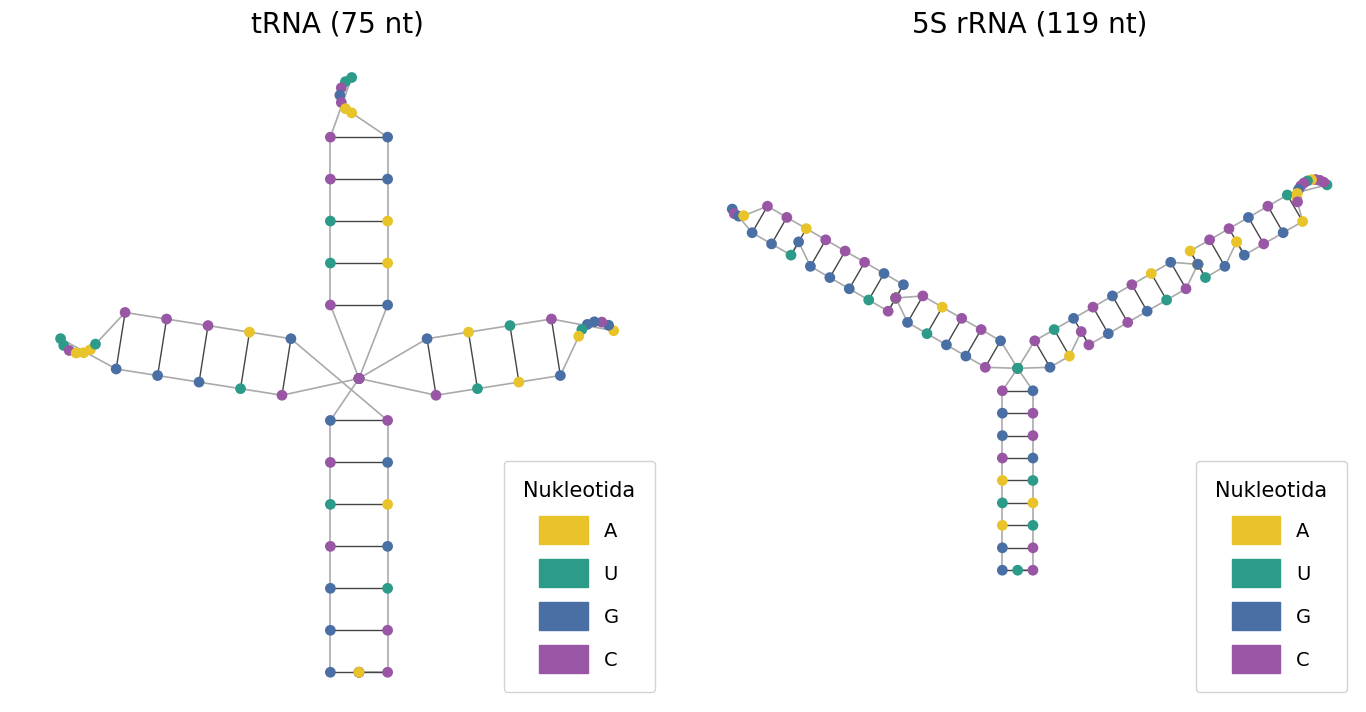

In [6]:
trna = next(r for r in records if r["family"] == "tRNA" and len(r["seq"]) < 90)
s5   = next(r for r in records if r["family"] == "5S_rRNA" and len(r["seq"]) < 130)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plot_rna_2d(trna["seq"], trna["reference"],
            title=f"tRNA ({len(trna['seq'])} nt)", ax=ax1)
plot_rna_2d(s5["seq"], s5["reference"],
            title=f"5S rRNA ({len(s5['seq'])} nt)", ax=ax2)
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)
fig.tight_layout()
plt.show()

#### Insights

> Pola pasangan basa tRNA membentuk kluster-kluster terpisah yang merupakan ciri khas struktur cloverleaf, dengan empat simpul yang menonjol. 5S rRNA menunjukkan distribusi pasangan basa yang lebih tersebar dengan tiga segmen heliks utama. Perbedaan topologi ini mengindikasikan bahwa algoritma Nussinov akan menghadapi tantangan berbeda pada tiap famili.

## Distribusi Sampel

Bar chart berikut menampilkan jumlah sekuens per famili RNA dalam dataset.

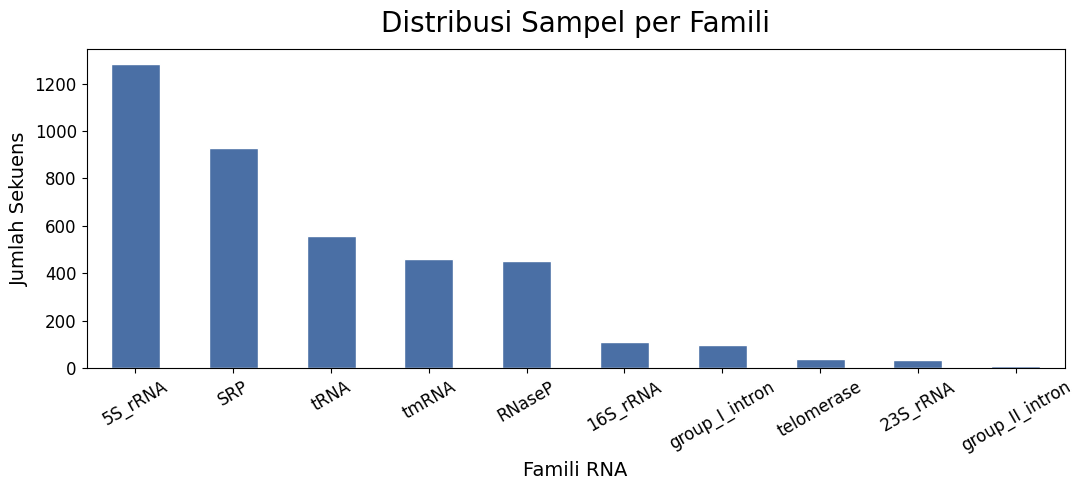

In [7]:
families_order = sorted(df_meta["family"].unique())

fig, ax = plt.subplots(figsize=(11, 5))
family_counts.plot.bar(x="family", y="count", ax=ax, legend=False,
                       color=CHART_COLOR, edgecolor="white")
ax.set_xlabel("Famili RNA", fontsize=14)
ax.set_ylabel("Jumlah Sekuens", fontsize=14)
ax.set_title("Distribusi Sampel per Famili", fontsize=20, pad=12)
ax.tick_params(axis="x", rotation=30, labelsize=12)
ax.tick_params(axis="y", labelsize=12)
fig.tight_layout()
plt.show()

#### Insights

> Jumlah sampel per famili bervariasi secara signifikan. Ketidakseimbangan ini menjadi alasan utama mengapa pelaporan akurasi per famili lebih informatif daripada rata-rata global sehingga famili dengan sedikit sampel tidak tenggelam dalam agregat.

## Distribusi Panjang Sekuens

Box plot berikut menampilkan sebaran panjang sekuens per famili RNA.

C:\Users\Razi\AppData\Local\Temp\ipykernel_16080\2129944788.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_family, labels=families_order, patch_artist=True,


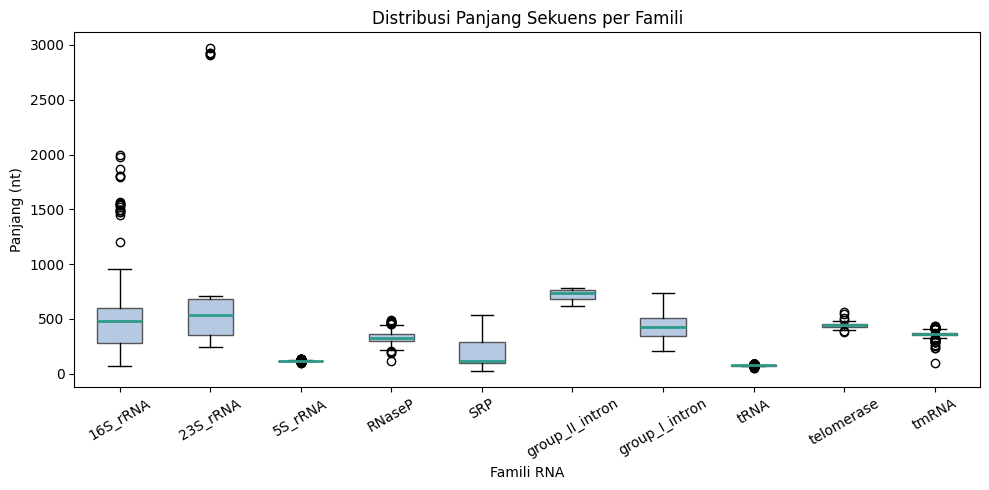

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
data_by_family = [
    df_meta[df_meta["family"] == f]["length"].values
    for f in families_order
]
ax.boxplot(data_by_family, labels=families_order, patch_artist=True,
           boxprops=dict(facecolor=BOX_FILL, color="#555555"),
           medianprops=dict(color=BOX_MEDIAN, linewidth=2))
ax.set_xlabel("Famili RNA")
ax.set_ylabel("Panjang (nt)")
ax.set_title("Distribusi Panjang Sekuens per Famili")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

#### Insights

> Terdapat variasi panjang sekuens yang signifikan antar famili. tRNA merupakan famili terpendek dengan distribusi yang sangat sempit, sedangkan group_II_intron dan 16S_rRNA memiliki rentang yang jauh lebih lebar. Sebagian sekuens 16S_rRNA melampaui 1000 nt sehingga menjadi *outlier* yang akan dikeluarkan pada tahap pembatasan berikutnya. Panjang sekuens berpengaruh langsung terhadap kompleksitas komputasi O(n^3) algoritma Nussinov.

## Pembatasan Panjang Sekuens

Berdasarkan distribusi panjang di atas, sekuens di atas `MAX_SEQ_LEN` nt ditetapkan di luar cakupan analisis. Sekuens tersebut merupakan *outlier* distribusi yang hanya muncul pada 23S_rRNA dan sebagian 16S_rRNA, sehingga tidak representatif terhadap mayoritas dataset. Batas ini ditetapkan sebelum prediksi dijalankan.

In [9]:
df_meta_full = df_meta.copy()
n_before     = len(records)
records      = [r for r in records if len(r["seq"]) <= CFG.MAX_SEQ_LEN]
df_meta      = df_meta[df_meta["length"] <= CFG.MAX_SEQ_LEN].reset_index(drop=True)

print(f"Sebelum filter     : {n_before} sekuens")
print(f"Setelah filter     : {len(records)} sekuens (<= {CFG.MAX_SEQ_LEN} nt)")
print(f"Sekuens dikeluarkan: {n_before - len(records)}")

Sebelum filter     : 3975 sekuens
Setelah filter     : 3950 sekuens (<= 1000 nt)
Sekuens dikeluarkan: 25


## GC Content vs Panjang Sekuens

Scatter plot dua panel berikut membandingkan distribusi GC content terhadap panjang sekuens sebelum dan sesudah pembatasan, diwarnai per famili.

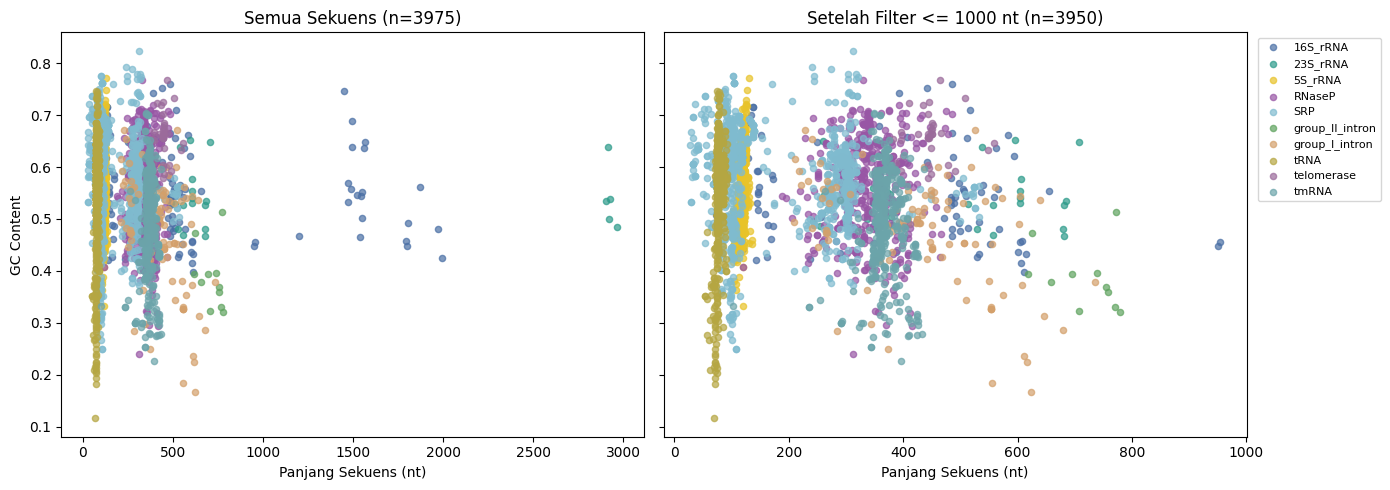

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for i, fam in enumerate(families_order):
    c = FAMILY_PALETTE[i % len(FAMILY_PALETTE)]
    sub_full = df_meta_full[df_meta_full["family"] == fam]
    sub_filt = df_meta[df_meta["family"] == fam]
    ax1.scatter(sub_full["length"], sub_full["gc"], label=fam,
                color=c, s=20, alpha=0.7)
    ax2.scatter(sub_filt["length"], sub_filt["gc"], label=fam,
                color=c, s=20, alpha=0.7)
for ax, title in [
    (ax1, f"Semua Sekuens (n={len(df_meta_full)})"),
    (ax2, f"Setelah Filter <= {CFG.MAX_SEQ_LEN} nt (n={len(df_meta)})"),
]:
    ax.set_xlabel("Panjang Sekuens (nt)")
    ax.set_title(title)
ax1.set_ylabel("GC Content")
ax2.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
fig.tight_layout()
plt.show()

#### Insights

> Panel kiri menunjukkan *outlier* panjang dari 16S_rRNA yang mendominasi sumbu horizontal. Panel kanan memperlihatkan distribusi yang lebih terpusat setelah pembatasan 25 sekuens dikeluarkan, dengan seluruh 10 famili tetap terwakili. Kandungan GC bervariasi antar famili dan membentuk kluster yang relatif terpisah, menunjukkan karakteristik komposisional yang berbeda per famili. Kandungan GC yang lebih tinggi berarti lebih banyak pasangan G-C potensial yang dapat ditemukan algoritma Nussinov.

---

# Algoritma Nussinov <a name="4"></a>

---

Algoritma Nussinov didemonstrasikan pada sekuens SRP RNA pendek dari `examples.json`. Sekuens ini dipilih karena panjangnya di bawah 100 nt sehingga matriks gamma dapat divisualisasikan secara lengkap dalam heatmap. Matriks diisi secara diagonal dari kiri bawah ke kanan atas; setiap sel merepresentasikan jumlah pasangan basa maksimum untuk subsequens yang bersangkutan.

## Matriks DP

Sel berikut memuat sekuens demo dari `examples.json`, membangun matriks gamma, dan memvisualisasikannya sebagai heatmap.

In [11]:
with open(CFG.EXAMPLES) as f:
    examples = json.load(f)

demo = next(e for e in examples if e["family"] == "SRP")
seq_demo = demo["sequence"]

print(f"Famili : {demo['family']}")
print(f"Panjang: {len(seq_demo)} nt")
print(f"Sekuens: {seq_demo}")

Famili : SRP
Panjang: 28 nt
Sekuens: CCGUCAGGUCCGGAAGGAAGCAGCGGUA


Jumlah pasangan basa maksimum (gamma[0][n-1]): 8


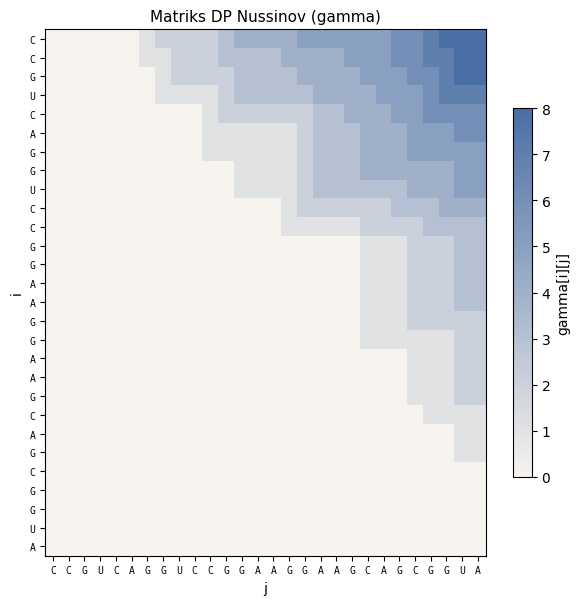

In [12]:
dp = build_dp_matrix(seq_demo)

print(f"Jumlah pasangan basa maksimum (gamma[0][n-1]): {dp[0][len(seq_demo)-1]}")

fig = plot_dp_matrix(dp, seq_demo)
plt.show()

#### Insights

> Nilai gamma meningkat dari diagonal utama (nol) ke sudut kiri atas, mencerminkan akumulasi pasangan basa seiring bertambahnya panjang subsequens. Pola warna yang terbentuk menggambarkan distribusi pasangan basa dalam sekuens, dengan area bernotasi tinggi menandai region yang kaya struktur.

## Arc Diagram

Traceback dari matriks gamma menghasilkan himpunan pasangan basa. Arc diagram memvisualisasikan pasangan tersebut sebagai busur di atas baseline sekuens sehingga crossing dan nesting terlihat jelas.

Dot-bracket: ..(((.(((((....)))..)..)))).
Jumlah pasangan basa: 8


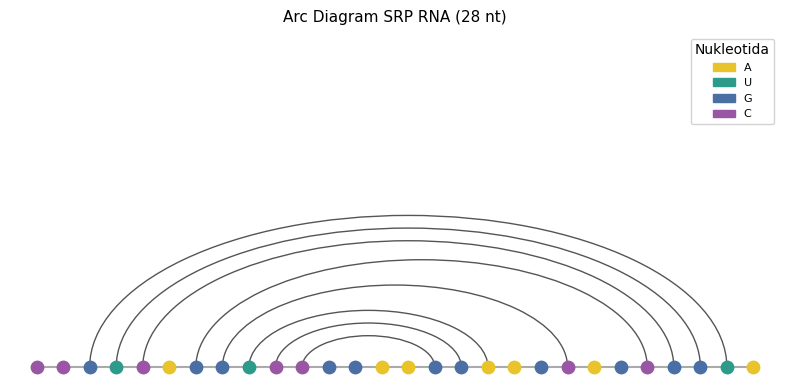

In [13]:
pairs_demo: set = set()
nussinov_traceback(dp, seq_demo, 0, len(seq_demo) - 1, pairs_demo)

dot_bracket_demo = ["." ] * len(seq_demo)
for i, j in pairs_demo:
    dot_bracket_demo[i] = "("
    dot_bracket_demo[j] = ")"

print(f"Dot-bracket: {''.join(dot_bracket_demo)}")
print(f"Jumlah pasangan basa: {len(pairs_demo)}")

fig = plot_arc_diagram(seq_demo, pairs_demo,
                       title=f"Arc Diagram SRP RNA ({len(seq_demo)} nt)")
plt.show()

#### Insights

> Busur-busur yang tidak bersilangan (nested) mencerminkan struktur heliks yang valid secara biologis. Algoritma Nussinov tidak dapat memprediksi pseudoknot (busur bersilangan) sehingga struktur yang dihasilkan selalu berupa secondary structure planar. Ini merupakan keterbatasan mendasar yang membedakannya dari metode berbasis energi bebas minimum.

---

# Prediksi Batch <a name="5"></a>

---

Prediksi struktur sekunder dijalankan pada seluruh dataset menggunakan `predict_structure`. Waktu komputasi per famili direkam untuk menganalisis pengaruh panjang sekuens terhadap efisiensi algoritma O(n^3).

In [14]:
results = []
timing = {}

for r in tqdm(records, desc="Prediksi", leave=True):
    fam = r["family"]
    t0  = time.perf_counter()
    pred_db = predict_structure(r["seq"])
    dt  = time.perf_counter() - t0

    predicted = parse_dot_bracket(pred_db)
    reference = r["reference"]

    results.append({
        "seq":       r["seq"],
        "family":    fam,
        "predicted": predicted,
        "reference": reference,
        "metrics":   compute_metrics(predicted, reference),
    })
    timing.setdefault(fam, []).append(dt)

print(f"Prediksi selesai: {len(results)} sekuens")

Prediksi: 100%|██████████| 3950/3950 [45:11<00:00,  1.46it/s]  

Prediksi selesai: 3950 sekuens


In [15]:
out_path = CFG.DATA_DIR / "results.json"
serializable = [
    {**r, "predicted": sorted(r["predicted"]), "reference": sorted(r["reference"])}
    for r in results
]
out_path.write_text(json.dumps(serializable, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Disimpan -> {out_path}  ({out_path.stat().st_size // 1024} KB)")

Disimpan -> ..\dataset\results.json  (25201 KB)


## Waktu Komputasi per Famili

Tabel berikut menampilkan rata-rata waktu komputasi (dalam milidetik) per famili RNA.

In [16]:
df_timing = pd.DataFrame([
    {
        "family":    fam,
        "n_samples": len(times),
        "mean_ms":   round(np.mean(times) * 1000, 2),
        "median_ms": round(np.median(times) * 1000, 2),
        "max_ms":    round(np.max(times) * 1000, 2),
    }
    for fam, times in sorted(timing.items())
])

display(df_timing)

,family,n_samples,mean_ms,median_ms,max_ms
0,16S_rRNA,90,2920.55,2013.53,24426.36
1,23S_rRNA,30,3873.92,3084.68,9788.52
2,5S_rRNA,1283,46.61,42.60,152.73
3,RNaseP,454,1095.35,958.69,4260.20
4,SRP,928,345.80,49.82,5160.46
5,group_II_intron,11,11087.58,12060.30,14250.67
6,group_I_intron,98,2808.48,2215.65,11465.67
7,tRNA,557,13.74,12.02,74.76
8,telomerase,37,2637.02,2496.52,5125.46
9,tmRNA,462,2055.44,1653.59,11719.36


#### Insights

> Waktu komputasi meningkat drastis seiring bertambahnya panjang sekuens, konsisten dengan kompleksitas O(n^3). tRNA memerlukan rata-rata 13,74 ms per sekuens sedangkan group_II_intron memerlukan rata-rata 11.088 ms, selisih lebih dari 800 kali lipat. Ini mengkonfirmasi keterbatasan praktis algoritma Nussinov pada sekuens yang sangat panjang.

---

# Evaluasi <a name="6"></a>

---

Metrik sensitivity, PPV, F1, dan MCC dihitung untuk setiap sekuens dengan membandingkan pasangan basa yang diprediksi terhadap referensi. Tabel ringkasan per famili menampilkan rata-rata per famili sesuai metodologi Mathews (2019), di mana setiap famili berkontribusi setara terhadap rata-rata keseluruhan.

## Ringkasan per Famili

Tabel berikut menampilkan rata-rata metrik akurasi per famili RNA, diurutkan berdasarkan F1 dari tertinggi ke terendah.

In [17]:
df_summary = analyze_by_family(results)
df_eval    = summarize(results)

display(df_summary.sort_values("f1", ascending=False).round(3))

,family,sensitivity,ppv,f1
7,tRNA,0.293,0.213,0.247
2,5S_rRNA,0.271,0.205,0.233
4,SRP,0.236,0.189,0.209
3,RNaseP,0.225,0.167,0.191
0,16S_rRNA,0.222,0.158,0.183
1,23S_rRNA,0.213,0.158,0.181
6,group_I_intron,0.212,0.136,0.163
5,group_II_intron,0.172,0.078,0.106
8,telomerase,0.125,0.075,0.094
9,tmRNA,0.065,0.042,0.050


#### Insights

> Terdapat variasi akurasi yang signifikan antar famili RNA. tRNA mencatat F1 tertinggi (0,247) sedangkan tmRNA mencatat F1 terendah (0,050), dengan rata-rata keseluruhan 0,166. Sensitivitas selalu lebih tinggi dari PPV di setiap famili, mengkonfirmasi kecenderungan Nussinov memprediksi pasangan basa berlebih. Famili dengan pseudoknot seperti tmRNA dan telomerase menunjukkan F1 terendah karena crossing pairs tidak dapat dimodelkan.

---

# Visualisasi Perbandingan <a name="7"></a>

---

Visualisasi perbandingan antara prediksi dan referensi dilakukan pada dua sekuens representatif: tRNA dan 5S rRNA. Pasangan basa diwarnai berdasarkan tipe kesalahan: TP hijau (benar diprediksi), FP merah (salah diprediksi), FN oranye (terlewat dari referensi).

## tRNA: Prediksi vs Referensi

Visualisasi berikut menampilkan perbandingan struktur prediksi dan referensi untuk satu sekuens tRNA representatif.

tRNA -- Sensitivity: 0.476, PPV: 0.357, F1: 0.408


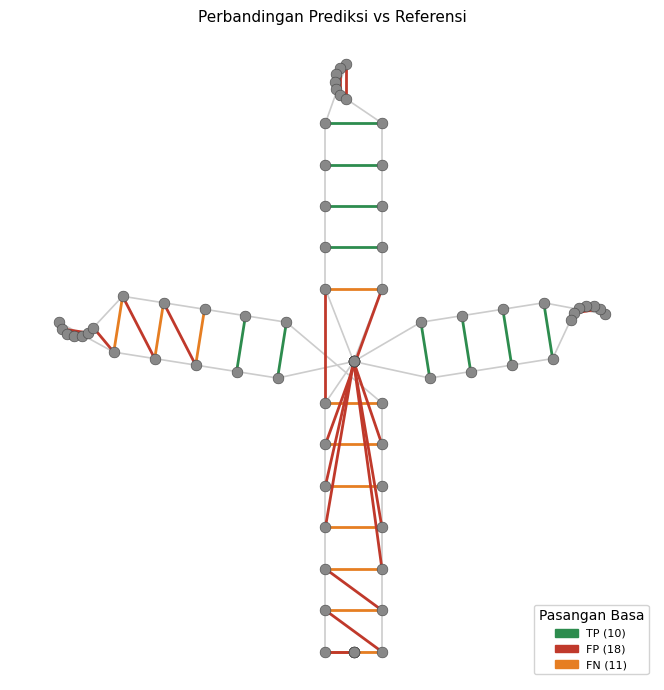

In [18]:
trna_res = next(r for r in results if r["family"] == "tRNA"
               and len(r["seq"]) < 90)

m = trna_res["metrics"]
print(f"tRNA -- Sensitivity: {m['sensitivity']:.3f}, "
      f"PPV: {m['ppv']:.3f}, F1: {m['f1']:.3f}")

fig = plot_comparison(
    trna_res["seq"],
    trna_res["predicted"],
    trna_res["reference"],
)
plt.show()

#### Insights

> Sekuens tRNA ini mencatat Sensitivity 0,476, PPV 0,357, dan F1 0,408, di atas rata-rata famili (0,247) karena strukturnya yang terkonservasi. TP (hijau) terkonsentrasi pada stem heliks utama cloverleaf. FP (merah) muncul di region loop yang kompatibel secara sekuens namun tidak berpasangan dalam referensi. FN (oranye) seringkali pada pasangan referensi di antikodon loop yang membutuhkan konteks termodinamika.

## 5S rRNA: Prediksi vs Referensi

Visualisasi serupa untuk satu sekuens 5S rRNA representatif.

5S rRNA -- Sensitivity: 0.611, PPV: 0.489, F1: 0.543


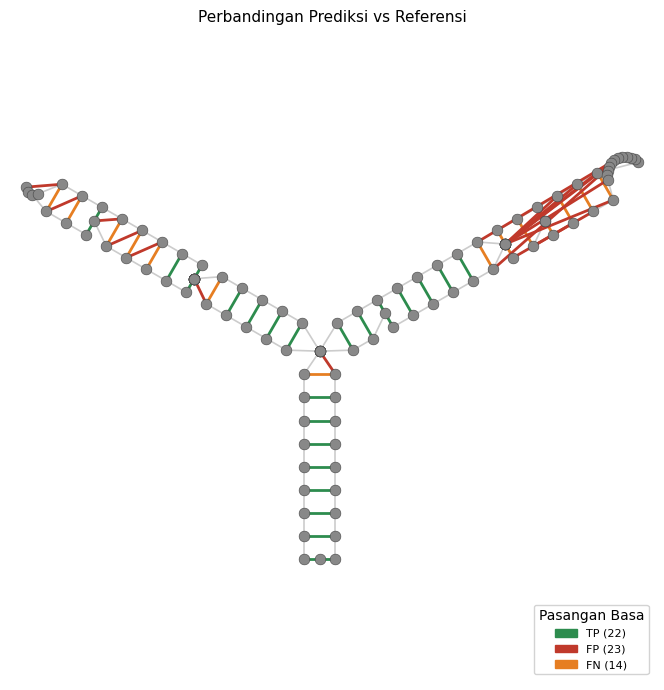

In [19]:
s5_res = next(r for r in results if r["family"] == "5S_rRNA"
              and len(r["seq"]) < 130)

m = s5_res["metrics"]
print(f"5S rRNA -- Sensitivity: {m['sensitivity']:.3f}, "
      f"PPV: {m['ppv']:.3f}, F1: {m['f1']:.3f}")

fig = plot_comparison(
    s5_res["seq"],
    s5_res["predicted"],
    s5_res["reference"],
)
plt.show()

#### Insights

> Sekuens 5S rRNA ini mencatat Sensitivity 0,611, PPV 0,489, dan F1 0,543, jauh di atas rata-rata famili (0,233) karena merupakan sekuens pendek dengan struktur yang sangat terkonservasi. Meskipun demikian, PPV tetap lebih rendah dari Sensitivity, menunjukkan masih ada FP pada region heliks alternatif yang valid secara komplementer namun tidak sesuai konteks biologis sesungguhnya.

---

# Analisis <a name="8"></a>

---

Analisis kuantitatif dilakukan untuk menjawab tiga pertanyaan penelitian: variasi F1 antar famili, pengaruh panjang sekuens terhadap F1, dan pengaruh kandungan GC terhadap F1.

## Akurasi per Famili

Bar chart berikut memvisualisasikan rata-rata F1 per famili RNA, diurutkan dari tertinggi ke terendah.

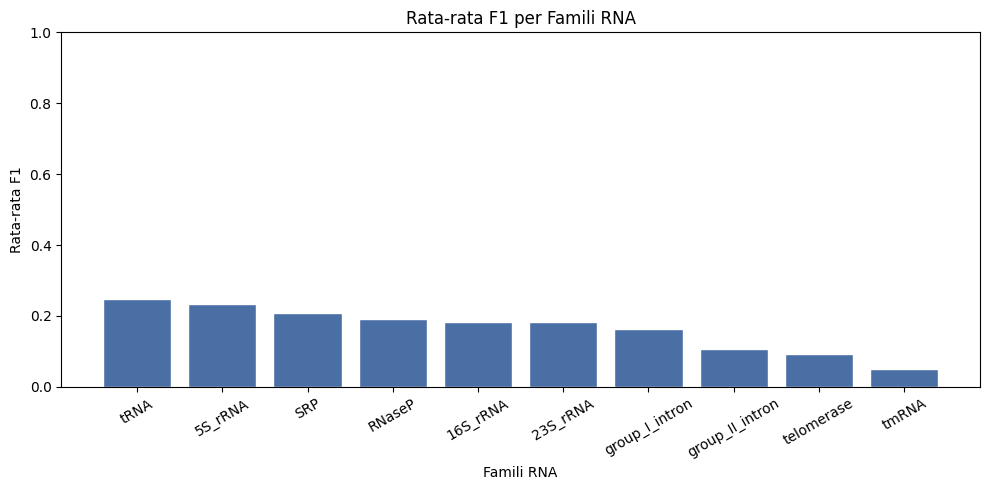

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
df_bar = df_summary.sort_values("f1", ascending=False)
ax.bar(df_bar["family"], df_bar["f1"],
       color=CHART_COLOR, edgecolor="white")
ax.set_xlabel("Famili RNA")
ax.set_ylabel("Rata-rata F1")
ax.set_title("Rata-rata F1 per Famili RNA")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

#### Insights

> Rentang F1 dari 0,050 (tmRNA) hingga 0,247 (tRNA) dengan rata-rata 0,166 menunjukkan bahwa algoritma Nussinov tidak bekerja secara seragam. tRNA dan 5S_rRNA unggul karena struktur pendek dan terkonservasi, sedangkan tmRNA dan telomerase berada di bawah karena arsitektur kompleks dengan pseudoknot yang tidak dapat dimodelkan oleh algoritma.

## Panjang Sekuens vs F1

Scatter plot berikut menampilkan hubungan antara panjang sekuens dan F1 untuk seluruh sampel, diwarnai per famili.

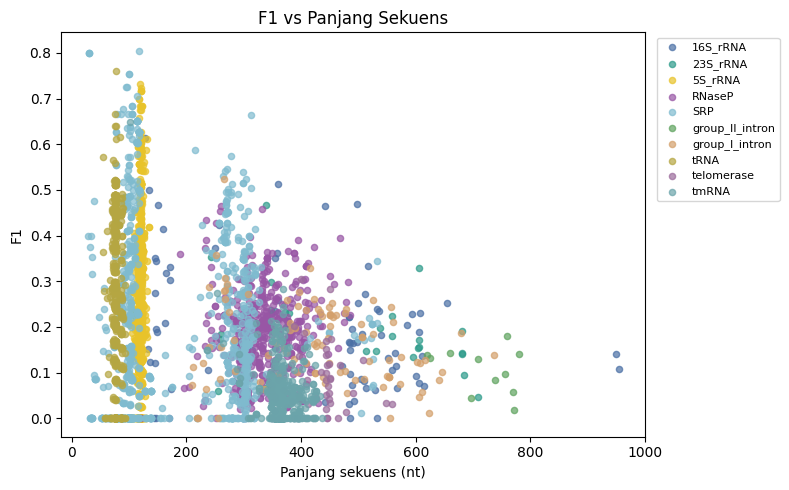

In [21]:
fig = plot_accuracy_vs_length(results)
plt.show()

#### Insights

> F1 menunjukkan kecenderungan menurun pada sekuens yang lebih panjang, meskipun dengan variasi yang besar. Sekuens pendek memberikan lebih sedikit kemungkinan pasangan alternatif sehingga peluang prediksi yang tepat lebih besar. Pada sekuens panjang, ruang solusi yang luas meningkatkan kemungkinan algoritma menemukan solusi yang suboptimal secara biologis.

## GC Content vs F1

Scatter plot berikut menampilkan hubungan antara kandungan GC dan F1 untuk seluruh sampel, diwarnai per famili.

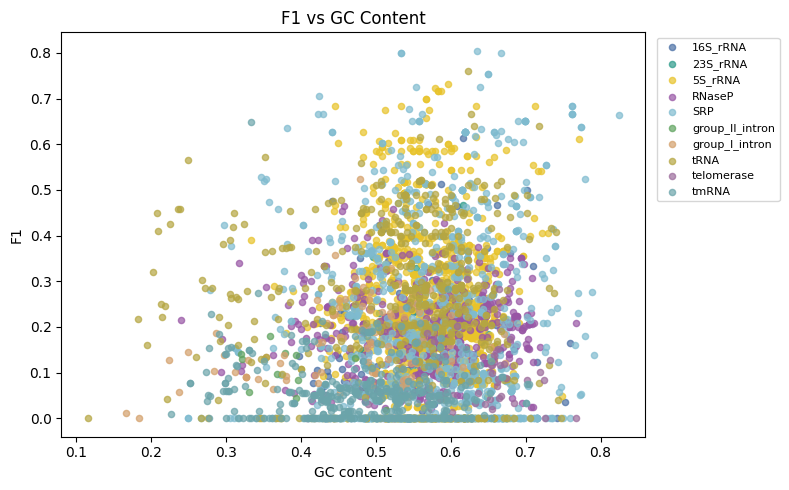

In [22]:
fig = plot_accuracy_vs_gc(results)
plt.show()

#### Insights

> Hubungan antara kandungan GC dan F1 tidak menunjukkan tren yang kuat dan linear. Meskipun kandungan GC yang lebih tinggi menyediakan lebih banyak pasangan basa potensial, hal ini tidak selalu menghasilkan prediksi yang lebih akurat karena algoritma Nussinov memaksimalkan kuantitas pasangan basa tanpa mempertimbangkan kualitas struktural biologis.

---

# Kesimpulan <a name="9"></a>

---

Algoritma Nussinov berhasil diimplementasikan dan dievaluasi secara sistematis pada dataset ArchiveII yang mencakup 10 famili RNA. Evaluasi ini merupakan yang pertama menggunakan metodologi pelaporan per famili yang direkomendasikan Mathews (2019) untuk algoritma klasik ini.

Akurasi prediksi bervariasi secara signifikan antar famili, dengan pola yang konsisten: famili dengan struktur sederhana dan konservat memperoleh F1 lebih tinggi, sementara famili dengan pseudoknot atau struktur kompleks menunjukkan F1 lebih rendah karena ketidakmampuan mendasar algoritma memodelkan crossing pairs.

Terdapat kecenderungan penurunan F1 pada sekuens panjang, konsisten dengan bertambahnya ruang solusi yang harus dieksplorasi. Kandungan GC tidak menunjukkan hubungan yang kuat dengan F1 karena kuantitas pasangan basa yang dimaksimalkan Nussinov tidak berkorelasi langsung dengan ketepatan struktural biologis.

Keterbatasan utama algoritma Nussinov adalah tidak dapat memprediksi pseudoknot, tidak mempertimbangkan energi bebas, dan memberikan solusi non-deterministik apabila terdapat banyak solusi optimal. Penelitian lanjutan sebaiknya membandingkan Nussinov dengan metode berbasis energi bebas minimum seperti RNAfold pada dataset yang sama untuk mengkuantifikasi perbaikan yang dapat diperoleh dengan mempertimbangkan termodinamika.

---

# Daftar Pustaka <a name="10"></a>

---

[1] R. Nussinov and A. B. Jacobson, "Fast algorithm for predicting the secondary structure of single-stranded RNA," *Proceedings of the National Academy of Sciences*, vol. 77, no. 11, pp. 6309-6313, 1980.

[2] Q. Zhao, Z. Zhao, X. Fan, Z. Yuan, Q. Mao, and Y. Yao, "Review of machine learning methods for RNA secondary structure prediction," *PLOS Computational Biology*, vol. 17, no. 8, e1009291, 2021.

[3] P. Danaee, M. Rouches, M. Wiley, D. Deng, L. Huang, and D. Hendrix, "bpRNA: large-scale automated annotation and analysis of RNA secondary structure," *Nucleic Acids Research*, vol. 46, no. 11, pp. 5381-5394, 2018.

[4] M. F. Sloma and D. H. Mathews, "Exact calculation of loop formation probability identifies folding motifs in RNA secondary structures," *RNA*, vol. 22, no. 12, pp. 1808-1818, 2016.

[5] D. H. Mathews, "How to benchmark RNA secondary structure prediction accuracy," *Methods*, vol. 162-163, pp. 60-67, 2019.

[6] M. Szikszai, M. Wise, A. Datta, M. Ward, and D. H. Mathews, "Deep learning models for RNA secondary structure prediction (probably) do not generalize across families," *Bioinformatics*, vol. 38, no. 16, pp. 3892-3899, 2022.